# <span style="color:green"> Numerical Simulation Laboratory (NSL)
#### Emma Franco
## <span style="color:blue">  Lecture 11</span>
### <span style= "color: black" > Es11.1


Lo scopo di questo esercizio è eseguire una regressione lineare su dati rumorosi utilizzando una *Rete Neurale (Neural Network, NN)*, con l'obiettivo di capire come questa dipenda dal numero di epoche, $N_{\mathrm{epochs}}$, dal numero di *training data*, $N_{\mathrm{train}}$, e dal rumore $\sigma$.

Si considera un processo stocastico descritto dalla coppia di valori $(x, y)$, legati dall'equazione
$$
y_i = f(x_i) + \eta_i,
$$
dove $f(x_i)$ è una funzione sconosciuta, e $\eta_i$ è una variabile casuale gaussiana tale che $\langle \eta_i \rangle = 0$ e $\langle \eta_i \eta_j \rangle = \delta_{ij}\sigma$.

Per poter fare previsioni corrette sui risultati di tale processo, è necessario allenare il NN su un opportuno *training set* $\{(x^{\mathrm{train}}_j,y^{\mathrm{train}}_j)\}$ e poi validarlo su un *validation/test set* $\{(x^{\mathrm{test}}_j,y^{\mathrm{test}}_j)\}$.

Infine, si valuta la performance della rete neurale confrontando le predizioni $\{y_j^{\text{pred}}\}$ con i valori veri $\{y_j^{\text{pred}}\}$. Il confronto viene eseguito con una metrica opportuna, come ad esempio l'*errore quadratico medio (mean-squared error, MSE)*, che nel test set è definito come
$$
MSE = \frac{1}{N_{\text{test}}} \sum_{j=1}^{N_{\text{test}}} (y_j^{\text{pred}} - y_j)^2
$$


La funzione lineare utilizzata in questo esercizio è
$$
f(x)=2x+1
$$
per $x \in [-1,1]$. Poiché la funzione da apprendere è lineare e associa un unico input scalare a un unico output scalare, è sufficiente implementare una rete costituita da un singolo neurone, con un input $x$ e un output $y=wx+b$. $w$ e $b$ sono, rispettivamente, il peso e il bias associati al neurone, i quali vengono ottimizzati allenando il NN. 

La simulazione è eseguita con $N_{\mathrm{epochs}}=30$, $N_{\mathrm{train}}=500$, $N_{\mathrm{test}}=50$ e $\sigma=0.2$.

Di seguito viene mostrato il confronto tra i dati di test e i dati corrispondenti al target, per vedere la differenza tra i dati rumorosi $\{(x^{\mathrm{test}}_j,y^{\mathrm{test}}_j)\}$ che verranno dati in input al NN e la legge esatta, senza rumore.


In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import os
from IPython.display import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Activation

# Parametri target di f(x)=m*x+b
m = 2 
b = 1 

# Parametri del NN
N_epochs = 30
N_train = 500
N_test = 50
sigma = 0.2

np.random.seed(0)

x_train = np.random.uniform(-1, 1, N_train)      # Genero casualmente gli input del training set
x_test = np.random.uniform(-1, 1, N_test)        # Genero casualmente gli input del validation/test set
x_test.sort()

y_train = np.random.normal(m * x_train + b, sigma) # Genero gli output del training set come f(x) + rumore gaussiano con deviazione standard sigma
y_test = np.random.normal(m * x_test + b, sigma)   # Genero gli output del test set come f(x) + rumore gaussiano con deviazione standard sigma

y_target = m * x_test + b                         # Genero gli output esatti per il confronto con le predizioni svolte sul test set

2026-07-20 23:13:51.500062: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


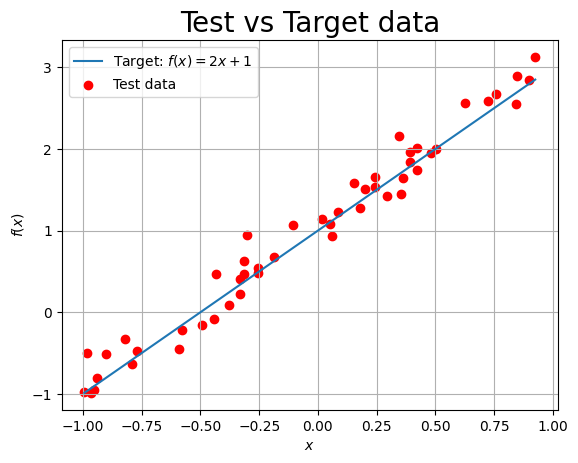

In [3]:
plt.plot(x_test, y_target, label='Target: $f(x) = 2x + 1$')
plt.scatter(x_test, y_test, color='r', label='Test data')
plt.xlabel('$x$', fontsize=10)
plt.ylabel('$f(x)$', fontsize=10)
plt.title('Test vs Target data', fontsize=20)
plt.grid(True)
plt.legend()

plt.show()

Si costruisce ora la NN: si utilizza un singolo layer costituito da un neurone.

Il grafico riportato di seguito mostra l'andamento della loss function (MSE) durante l'addestramento, calcolata sul training set e sul test set.

In [4]:
opt = 'sgd'    # Optimizer
lf = 'mse'     # Loss function: MSE

model = Sequential()    # Modello del NN
model.add(Input(shape=(1,)))  # Variabile di input
model.add(Dense(1))    # Variabile di output: 1 neurone connesso direttamente all'input
model.compile(optimizer=opt, loss=lf, metrics=['mse'])  # Completo il modello con optimizer, loss function e metrica

# Alleno il modello usando il training set
history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=N_epochs,
          shuffle=True, verbose=0, 
          validation_data=(x_test, y_test))

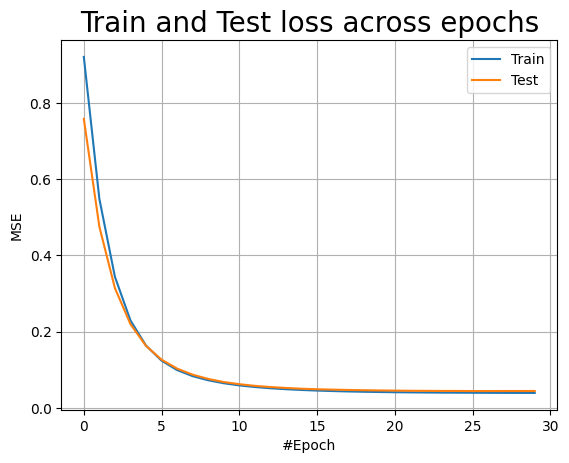

Performance del modello:
Test loss =  0.04451203718781471

Performance del modello con la curva esatta:
Target loss =  0.0004842726048082113


In [5]:
# Train e test loss
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.ylabel('MSE', fontsize=10)
plt.xlabel('#Epoch', fontsize=10)
plt.title('Train and Test loss across epochs', fontsize=20)
plt.grid(True)
plt.legend()

plt.show()



print('Performance del modello:')
# Valuto il modello con il test set
mse = model.evaluate(x_test, y_test, batch_size=32, verbose=0)
print('Test loss = ', mse[0])
print()
# Valuto il modello con la curva esatta
print('Performance del modello con la curva esatta:')
mse = model.evaluate(x_test, y_target, batch_size=32, verbose=0)
print('Target loss = ', mse[0])

Si può osservare che l'errore, in entrambi i casi, decresce rapidamente, fino a raggiungere un valore prossimo allo zero.
Il valore di partenza è alto, in quanto i parametri del NN, $w$ e $b$, sono inizializzati casualmente.

Questo andamento indica che il modello apprende correttamente la relazione tra i dati (legge lineare) e che non si verifica overfitting, ovvero è in grado di generalizzare anche su dati che non appartengono al training set.  

Inoltre, l'errore calcolato sui dati di test risulta essere leggermente superiore dell'errore calcolato a partire dai dati "target". Questo è dovuto alla presenza del rumore nei dati di test. Infine, il fatto che l'errore calcolato sui dati "target" sia basso significa che la NN ha imparato la legge lineare $f(x)=2x+1$ correttamente.

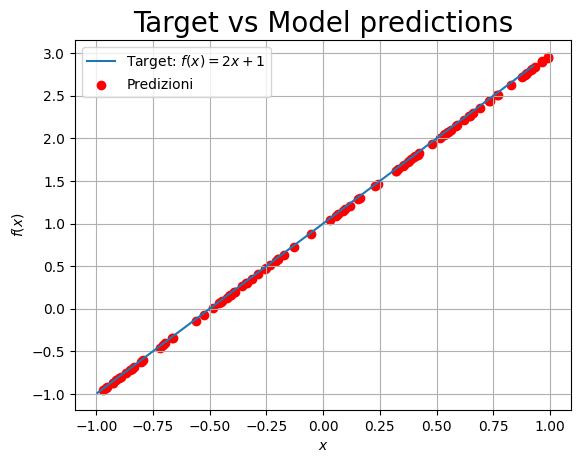

In [6]:
# Target vs test
x_predicted = np.random.uniform(-1, 1, 100)
y_predicted = model.predict(x_predicted, verbose=0)

plt.plot(x_test, y_target, label='Target: $f(x) = 2x + 1$')
plt.scatter(x_predicted, y_predicted, color='r', label='Predizioni')
plt.xlabel('$x$', fontsize=10)
plt.ylabel('$f(x)$', fontsize=10)
plt.title('Target vs Model predictions', fontsize=20)
plt.grid(True)
plt.legend()

plt.show()

Dal grafico si osserva che i valori predetti dal modello sono in ottimo accordo con l'andamento lineare teorico. Questo indica, ancora una volta, che i valori dei parametri della rete sono vicini a quelli esatti ($w=2$ e $b=1$).

Il NN implementato è stato in grado di apprendere e riprodurre la funzione lineare $f(x)=2x+1$.

Infine, si è provato ad implementare diversi NN, mantenendo fissate due quantità tra $N_{\mathrm{epochs}}$, $N_{\mathrm{train}}$ e $\sigma$, e variando l'altra. Di seguito si mostrano la procedura eseguita e i risultati della valutazione delle reti ottenute.

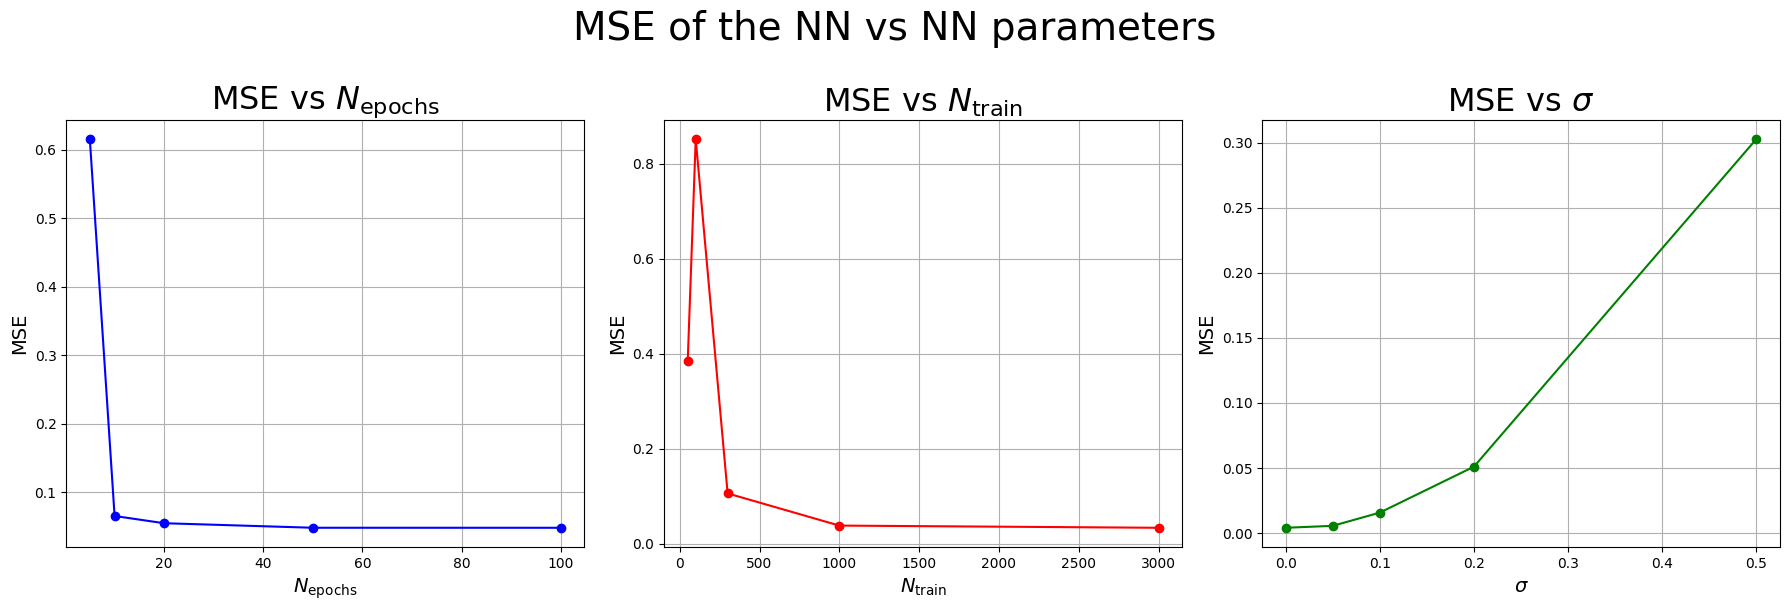

In [7]:
# Variazione dei parametri
def run(N_epochs, N_train, sigma):
    np.random.seed(0)
    x_train = np.random.uniform(-1, 1, N_train)
    y_train = np.random.normal(m * x_train + b, sigma)
    y_test = np.random.normal(m * x_test + b, sigma)

    model = Sequential()
    model.add(Input(shape=(1,)))
    model.add(Dense(1))
    model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

    model.fit(x_train, y_train,
              batch_size=32, epochs=N_epochs,
              shuffle=True, verbose=0,
              validation_data=(x_test, y_test))

    mse = model.evaluate(x_test, y_test, verbose=0)[0]
    return mse

# Lista parametri
N_epochs_list = [5, 10, 20, 50, 100]
N_train_list = [50, 100, 300, 1000, 3000]
sigma_list = [0.0, 0.05, 0.1, 0.2, 0.5]

mse_N_epochs = [run(ne, 500, 0.2) for ne in N_epochs_list]
mse_N_train = [run(30, nt, 0.2) for nt in N_train_list]
mse_sigma  = [run(30, 500, sg) for sg in sigma_list]

fig, axs = plt.subplots(1,3,figsize=(18, 6))
fig.suptitle('MSE of the NN vs NN parameters', fontsize=28, y=1.01)

# Epoche
axs[0].plot(N_epochs_list, mse_N_epochs, 'o-', color='b')
axs[0].set_xlabel('$N_{\mathrm{epochs}}$', fontsize=14)
axs[0].set_ylabel('MSE', fontsize=14)
axs[0].set_title('MSE vs $N_{\mathrm{epochs}}$', fontsize=23)
axs[0].grid(True)

# Dati train
axs[1].plot(N_train_list, mse_N_train, 'o-', color='r')
axs[1].set_xlabel('$N_{\mathrm{train}}$', fontsize=14)
axs[1].set_ylabel('MSE', fontsize=14)
axs[1].set_title('MSE vs $N_{\mathrm{train}}$', fontsize=23)
axs[1].grid(True)

# Rumore
axs[2].plot(sigma_list, mse_sigma, 'o-', color='g')
axs[2].set_xlabel('$\sigma$', fontsize=14)
axs[2].set_ylabel('MSE', fontsize=14)
axs[2].set_title('MSE vs $\sigma$', fontsize=23)            
axs[2].grid(True)
            
plt.tight_layout()
plt.show()

Si osserva che:  

- Un numero troppo basso di epoche non è sufficiente a garantire la convergenza del MSE. La convergenza si osserva con $N_{\mathrm{epochs}} \gtrsim 50$
- Se il training set è troppo piccolo, la test loss risulta elevata. Ciò indica una scarca capacità di generalizzazione del NN.
- Al crescere del rumore, l'errore cresce. Questo è dovuto alla maggior difficoltà nell'apprendere e ricostruire la legge "nascosta" tra i dati. Se invece $\sigma=0$ la rete riesce ad apprendere in modo esatto la legge $f(x)$

### <span style= "color: black" > Es11.2

In questo esercizio si estende il modello precedente allo scopo di realizzare un fit per il seguente polinomio di terzo grado:
$$
f(x)=4-3x-2x^2+3x^3
$$
per $x \in [-1,1]$.

La rete viene costruita scegliendo l'architettura (numero di layer e di neuroni per layer), la funzione di attivazione, l'ottimizzatore e la loss function opportuni. Si cerca di valutare come il modello si comporta con dati nuovi, sia all'interno del range $[-1,1]$ che all'esterno.

La procedura svolta è analoga a quella dell'esercizio precedente, con $N_{\mathrm{epochs}} = 50$, $N_{\mathrm{train}} = 2000$, $N_{\mathrm{test}} = 200$ e $\sigma = 0.1$. Inoltre, questa volta bisogna apprendere una funzione *non-lineare* che associa un input scalare ad un output scalare. Per questo motivo è necessario utilizzare diversi layer. La struttura della rete è mostrata di seguito.

In [8]:
# Parametri target di f(x)=ax^3+bx^2+cx+d
a = 3 
b = -2
c = -3
d = 4
def f(x):
    return a*x**3 + b*x**2 + c*x + d

# Parametri del NN
N_epochs = 50
N_train = 2000 
N_test = 200
sigma = 0.1

np.random.seed(0)

x_train = np.random.uniform(-1, 1, N_train)   # Genero casualmente gli input del training set
x_test = np.random.uniform(-1, 1, N_test)     # Genero casualmente gli input del validation/test set
x_test.sort()

y_train = np.random.normal(f(x_train), sigma) # Genero gli output del training set come f(x) + rumore gaussiano con deviazione standard sigma
y_test = np.random.normal(f(x_test), sigma)   # Genero gli output del test set come f(x) + rumore gaussiano con deviazione standard sigma

y_target = f(x_test)                          # Genero gli output esatti per il confronto con le predizioni svolte sul test set       

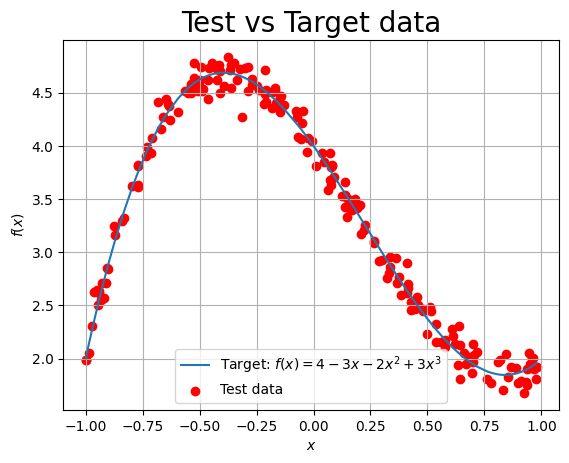

In [9]:
plt.plot(x_test, y_target, label='Target: $f(x)=4-3x-2x^2+3x^3$')
plt.scatter(x_test, y_test, color='r', label='Test data')
plt.xlabel('$x$', fontsize=10)
plt.ylabel('$f(x)$', fontsize=10)
plt.title('Test vs Target data', fontsize=20)
plt.grid(True)
plt.legend()

plt.show()

Come funzione di attivazione è stata scelta `tanh`, in quanto è adatta all'approssimazione di funzioni smooth; come ottimizzatore è stato scelto `adam`; come funzione di loss è stata scelta `mse`.

In [10]:
opt = 'adam'   # Optimizer
lf = 'mse'     # Loss function: MSE
act = 'tanh'   # Funzione di attivazione

model = Sequential()       # Modello del NN
model.add(Input(shape=(1,)))   # Variabile di input
model.add(Dense(32, activation=act))   # Primo layer: 32 neuroni, ciascuno collegato all'input
model.add(Dense(16, activation=act))   # Secondo layer: 16 neuroni, ciascuno collegato ad ogni output del layer precedente
model.add(Dense(8, activation=act))    # Terzo layer: 8 neuroni, ciascuno collegato ad ogni output del layer precedente
model.add(Dense(1))    # Layer/variabile di output: 1 neurone connesso ad ogni output del layer precedente
model.compile(optimizer=opt, loss=lf, metrics=['mse'])  # Completo il modello con optimizer, loss function e metrica

# Alleno il modello usando il training set
history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=N_epochs,
          shuffle=True, verbose=0, 
          validation_data=(x_test, y_test))

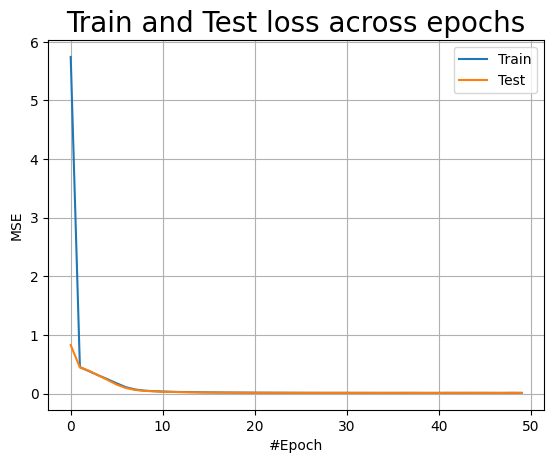

Performance del modello:
Test loss =  0.01144394837319851

Performance del modello con la curva esatta:
Target loss =  0.0020496107172220945


In [11]:
# Train e test loss
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.ylabel('MSE', fontsize=10)
plt.xlabel('#Epoch', fontsize=10)
plt.title('Train and Test loss across epochs', fontsize=20)
plt.grid(True)
plt.legend()

plt.show()

print('Performance del modello:')
# Valuto il modello con il test set
mse = model.evaluate(x_test, y_test, batch_size=32, verbose=0)
print('Test loss = ', mse[0])
print()
# Valuto il modello con la curva esatta
print('Performance del modello con la curva esatta:')
mse = model.evaluate(x_test, y_target, batch_size=32, verbose=0)
print('Target loss = ', mse[0])



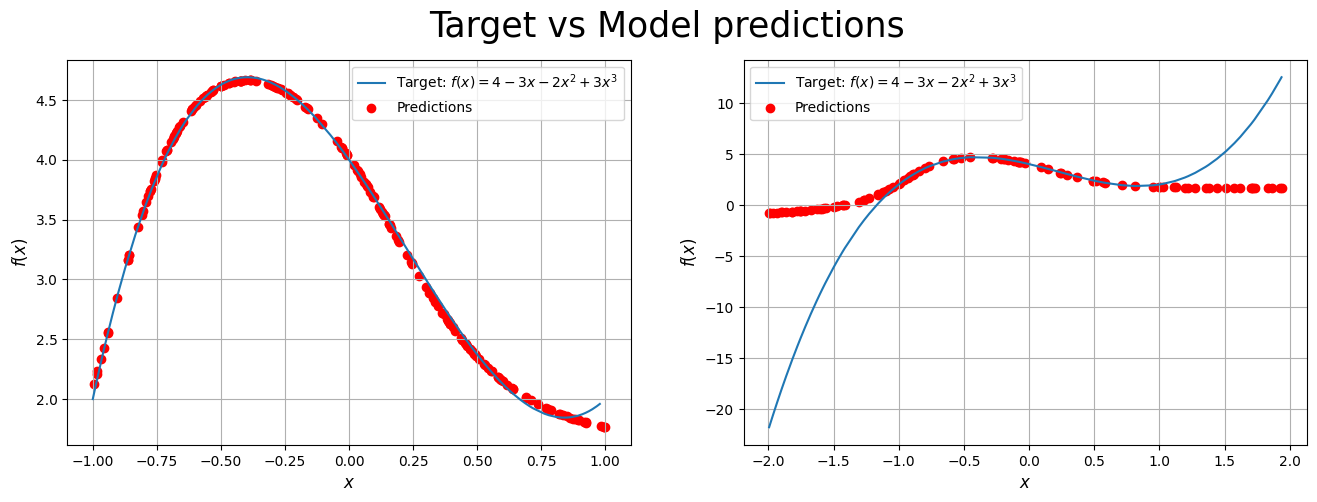

In [12]:
# Target vs test
plt.figure(figsize=(16,5))
plt.suptitle('Target vs Model predictions', fontsize=25)

x_predicted = np.random.uniform(-1, 1, 200)
y_predicted = model.predict(x_predicted, verbose=0)
plt.subplot(1,2,1)
plt.plot(x_test, f(x_test), label='Target: $f(x)=4-3x-2x^2+3x^3$')
plt.scatter(x_predicted, y_predicted, color='r', label='Predictions')
plt.xlabel('$x$', fontsize=12)
plt.ylabel('$f(x)$', fontsize=12)
plt.grid(True)
plt.legend()

x_predicted = np.random.uniform(-2, 2, 100)
x_predicted.sort()
y_predicted = model.predict(x_predicted, verbose=0)
plt.subplot(1,2,2)
plt.plot(x_predicted, f(x_predicted), label='Target: $f(x)=4-3x-2x^2+3x^3$')
plt.scatter(x_predicted, y_predicted, color='r', label='Predictions')
plt.xlabel('$x$', fontsize=12)
plt.ylabel('$f(x)$', fontsize=12)
plt.grid(True)
plt.legend()

plt.show()



Le predizioni della rete neurale realizzata risultano in buon accordo con la funzione target all’interno dell’intervallo di training $[-1,1]$, con errore $MSE \approx 0.01$.

In questo esercizio è stato necessario utilizzare più epoche di addestramento ($N_{\mathrm{epochs}} = 50$) e più dati di training ($N_{\mathrm{train}} = 2000$) rispetto al caso precedente, in quanto la funzione da apprendere è più complessa.

E' interessante notare che al di fuori di $[-1,1]$ la predizione del NN non è più in accordo con il target. Ciò evidenzia come la rete apprenda correttamente nell’intervallo di training, ma non sia in grado di generalizzare in modo affidabile oltre tale dominio.

### <span style= "color: black" > Es11.3

In questo esercizio si estende ulteriormente il modello per fittare la seguente funzione $\mathbb{R}^2\rightarrow\mathbb{R}$ non polimoniale:
$$
f(x,y)=\sin(x^2+y^2)
$$
entro il dominio $x \in [-3/2,3/2]$ e $y \in [-3/2,3/2]$.

Seguendo nuovamente la stessa procedura mostrata in precedenza, con $N_{\mathrm{epochs}}=50$, $N_{\mathrm{train}}=8000$, $N_{\mathrm{test}}=1000$ e $\sigma=0.1$, ed usando i medesimi ottimizzatore, loss function, funzione di attivazione, e architettura del NN:

In [13]:
# f(x,y)=sin(x^2+y^2)
def f(x,y):
    return np.sin((x*x + y*y))

# Parametri del NN
N_epochs = 50
N_train = 8000
N_test = 1000
sigma = 0.1

np.random.seed(0)

x_train = np.random.uniform(-1.5, 1.5, N_train)    # Genero casualmente gli input del training set
y_train = np.random.uniform(-1.5, 1.5, N_train)    # Genero casualmente gli input del training set
xy_train = np.column_stack((x_train, y_train))
x_test = np.random.uniform(-1.5, 1.5, N_test)      # Genero casualmente gli input del validation/test set
y_test = np.random.uniform(-1.5, 1.5, N_test)      # Genero casualmente gli input del validation/test set
xy_test = np.column_stack((x_test, y_test))

z_train = np.random.normal(f(x_train,y_train), sigma)  # Genero gli output del training set come f(x,y) + rumore gaussiano con deviazione standard sigma
z_test = np.random.normal(f(x_test,y_test), sigma)     # Genero gli output del test set come f(x,y) + rumore gaussiano con deviazione standard sigma

z_target = f(x_test, y_test)                         # Genero gli output esatti per il confronto con le predizioni svolte sul test set    

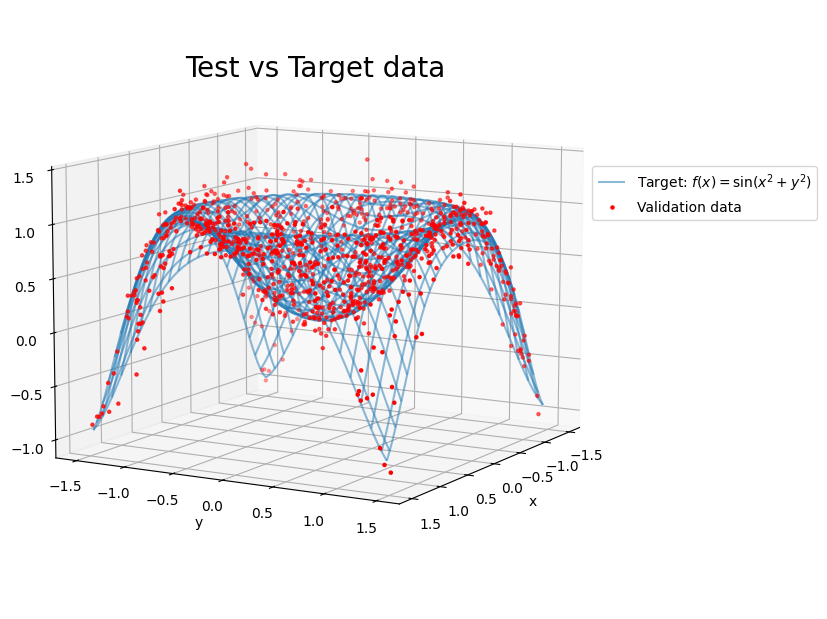

In [14]:
fig = plt.figure(figsize = (6,6))
ax = Axes3D(fig)
fig.add_axes(ax)

x_surf = np.arange(-1.5,1.5, 0.05)
y_surf = np.arange(-1.5,1.5, 0.05)
X_surf, Y_surf = np.meshgrid(x_surf,y_surf)
ax.plot_wireframe(X_surf, Y_surf, f(X_surf,Y_surf), alpha = 0.5, label='Target: $f(x)=\sin(x^2+y^2)$')
ax.scatter(x_test, y_test, z_test, marker = '.', color = 'r', label='Validation data')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.title('Test vs Target data', fontsize=20, y=0.95)
ax.view_init(10, 30)
ax.legend(bbox_to_anchor=(0.95, 0.75))

plt.show()

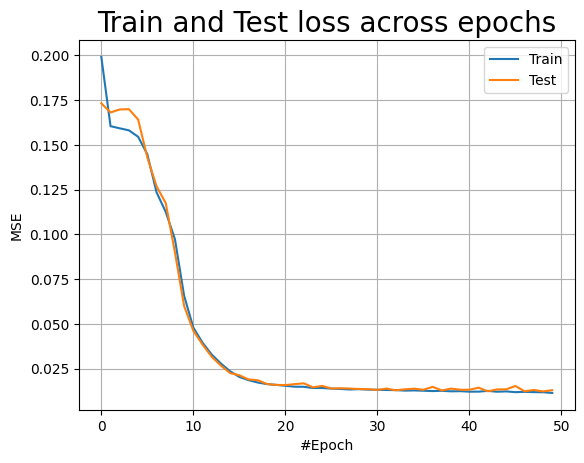

Performance del modello:
Test loss =  0.012941360473632812

Performance del modello con la curva esatta:
Test loss =  0.002373388735577464


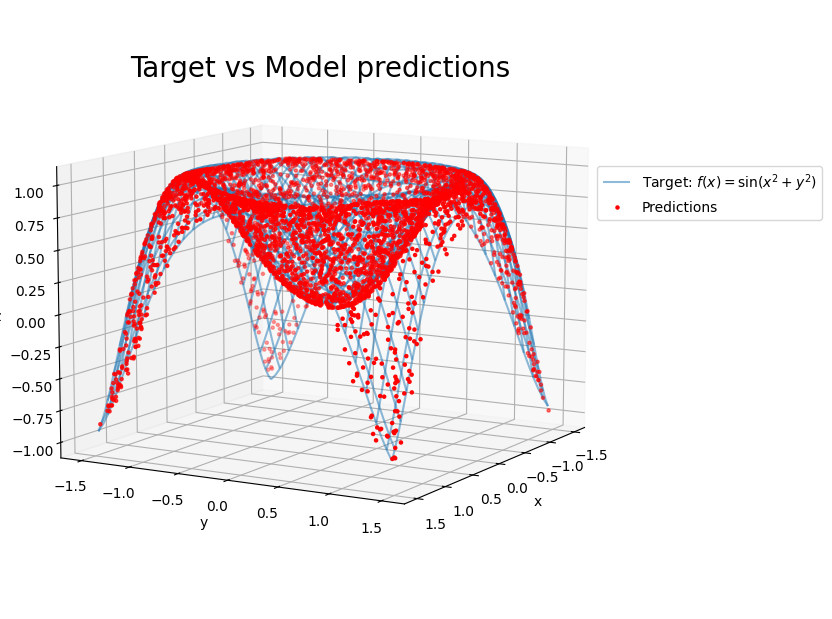

In [15]:
opt = 'adam'   # Optimizer
lf = 'mse'     # Loss function: MSE
act = 'tanh'   # Activation function

model = Sequential()       # Modello del NN
model.add(Input(shape=(2,)))   # Variabile di input (bidimensionale)
model.add(Dense(32, activation=act))   # Primo layer: 32 neuroni, ciascuno collegato a ciascun input
model.add(Dense(16, activation=act))   # Secondo layer: 16 neuroni, ciascuno collegato ad ogni output del layer precedente
model.add(Dense(8, activation=act))    # Terzo layer: 8 neuroni, ciascuno collegato ad ogni output del layer precedente
model.add(Dense(1))    # Layer/variabile di output: 1 neurone connesso ad ogni output del layer precedente
model.compile(optimizer=opt, loss=lf, metrics=['mse']) # Completo il modello con optimizer, loss function e metrica

# Alleno il modello usando il training set
history = model.fit(x=xy_train, y=z_train, 
          batch_size=32, epochs=N_epochs,
          shuffle=True, verbose=0, 
          validation_data=(xy_test, z_test))

# Train and test loss
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.ylabel('MSE', fontsize=10)
plt.xlabel('#Epoch', fontsize=10)
plt.title('Train and Test loss across epochs', fontsize=20)
plt.grid(True)
plt.legend()

plt.show()

print('Performance del modello:')
# Valuto il modello con il test set
mse = model.evaluate(xy_test, z_test, batch_size=32, verbose=0)
print('Test loss = ', mse[0])
print()
# Valuto il modello con la curva esatta
print('Performance del modello con la curva esatta:')
mse = model.evaluate(xy_test, z_target, batch_size=32, verbose=0)
print('Test loss = ', mse[0])


# Target vs test
fig = plt.figure(figsize = (6,6))
ax = Axes3D(fig)
fig.add_axes(ax)

x_predicted = np.random.uniform(-1.5, 1.5, 4000)           
y_predicted = np.random.uniform(-1.5, 1.5, 4000)
xy_predicted = np.column_stack((x_predicted, y_predicted))
z_predicted = model.predict(xy_predicted, verbose=0).ravel()  

x_surf = np.arange(-1.5,1.5, 0.05)
y_surf = np.arange(-1.5,1.5, 0.05)
X_surf, Y_surf = np.meshgrid(x_surf,y_surf)
ax.plot_wireframe(X_surf, Y_surf, f(X_surf,Y_surf), alpha = 0.5, label='Target: $f(x)=\sin(x^2+y^2)$')
ax.scatter(x_predicted, y_predicted, z_predicted, marker = '.', color = 'r', label='Predictions')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.title('Target vs Model predictions', fontsize=20, y=0.95)
ax.view_init(10, 30)
ax.legend(bbox_to_anchor=(0.95, 0.75))

plt.show()

I risultati appena mostrati evidenziano che le predizioni del NN risultano in buon accordo con la funzione $f(x,y)$ nel dominio di interesse, con un errore dato da $MSE \approx 0.01$. Esso è stato quindi in grado di apprendere correttamente l’andamento di $f$. 

E' importante osservare che per ottenere questo risultato è stato necessario aumentare significativamente il numero di dati di training ($N_{\mathrm{train}} = 8000$). Infatti, essendo adesso il dominio da esplorare molto più grande, in quanto bidimensionale, è fondamentale utilizzare un numero di dati fortemente maggiore per campionarlo in modo sufficientemente accurato.